In [34]:
!pip install langgraph

In [35]:
!pip install langchain

In [36]:
!pip install langgraph langchain_groq
from langgraph.graph import StateGraph,START,END,add_messages
from typing import TypedDict,Annotated
from langchain_core.messages import BaseMessage,HumanMessage
from langchain_groq import ChatGroq

-   what is basemessgae :
  - base messgae is system messgae, human messgae , Ai messgae
  - all these type of messgae is inheritant from base messgae
  -list[BaseMessage] : meaning this base messgae can be list of human messgae , system messgae and ai messgae
  -we will use resuer function
  -user ask what is capital of india {human messgae}
  -reply by llm is ai message
  -so ai msg  should not get replaced by human msg
  -that why we do redidula add  list=[human msg, ai msg]
 -messgae :Annotated[list[str]]

```
but in our system we use add_messgae
instead of operator.add
when we use baseMessge we dont use opertor.add
we use add_messages
it is built in in lang graph
from langraph.graph import add_messgae
use of this function is recommented when
w

In [37]:
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=""
)

In [38]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [39]:
def chat_node(state: ChatState):

    # take user query from state
    messages = state['messages']

    # send to llm
    response = llm.invoke(messages)

    # response store state
    return {'messages': [response]}

In [40]:
graph = StateGraph(ChatState)

# add nodes
graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile()

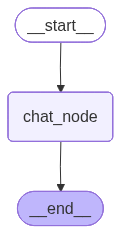

In [41]:
chatbot

In [42]:
initial_state = {
    'messages': [HumanMessage(content='What is the capital of usa')]
}

chatbot.invoke(initial_state)['messages'][-1].content

'The capital of the United States of America (USA) is **Washington, D.C.** (short for District of Columbia).'

In [43]:
while True:

    user_message = input('user messgae: ')



    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        break

    response = chatbot.invoke({
        'messages': [HumanMessage(content=user_message)]
    })

    print('AI:', response['messages'][-1].content)

user messgae: hi
AI: It's nice to meet you. Is there something I can help you with or would you like to chat?
user messgae: a=2 +2
AI: To solve for 'a', we need to add 2 and 2.

a = 2 + 2
a = 4

So, the value of 'a' is 4.
user messgae: what is value of a
AI: I don't have enough information to determine the value of "a". Could you please provide more context or clarify what "a" refers to? Is it a variable in a mathematical equation, a constant, or something else?
user messgae: quit


```
when we write the code why do this chat bot
is not able to remenber any thing
when we are sending whole         'messages': [HumanMessage(content=user_message)]
when this is list of all past converation
reason
then whole chatbot is getting invoke again and again from starting
```

```
when we do
invoke
when we write the code why do this chat bot
is not able to remenber any thing past converstaion
```

```
we are doing invoke chatbot (start  >>>  chat_node >>>  end)
invoke second time we do ( chat_node >> end)  
no instaed we do
chat_bot(start  >>> chat_node  >> end)
```

```
the solution of these problem
teh per sis tance memory
per man
per sis tance    memoery

basic meaning is that when u u come 2 the end
stae is not replecd instaed it is
state = pervious state + after state

means u basically store the pervious state some where

where to store
database(used in industry) and ram memory(for basic chat bot )


how thsi is done
-------------------------------------------
- from langraph.cheackpionter import memorysaver
-------------------------------------------
```

---------------------
now the graph code change

-------------

In [47]:
from langgraph.checkpoint.memory import MemorySaver

In [50]:
checkpointer=MemorySaver()

graph = StateGraph(ChatState)

# add nodes
graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile(checkpointer=checkpointer) # when u are compliering the graph
# u just tell ur graph taht there is check pionter
# we just tell our graph that our graph is check pointer
# this check pionter is memorysaver object

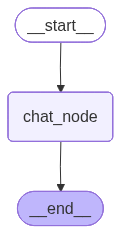

In [51]:
chatbot

In [56]:
chatbot.invoke(
    {'messages': [HumanMessage(content='hi')]},
    config={'configurable': {'thread_id': '1'}}
)['messages'][-1].content

"You're on a roll with the hellos. If you're ready to move beyond greetings, I'm here to listen and chat about anything that's on your mind. What's new with you?"

```
when u are invoking the graph
u need to difine what is theard

what is therad
>> one interaction with chat bot

nitish intercation >> one thread
rahul interaction >> on ethread

before response i guess there will on configure variable  
the value of this configure will be have one thread if

that thread id will be same as u define before
```

In [60]:
thread_id='1'
while True:

    user_message = input('user messgae: ')



    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        break
    # here u made the config key
    # which is a dictionary
    # and the value of the dictionary will be a dict itself
    config = {'configurable': {'thread_id': thread_id}}
    response = chatbot.invoke(
        {'messages': [HumanMessage(content=user_message)]},
        config=config
    ) # we will add config variable here okay

    print('AI:', response['messages'][-1].content)

user messgae: hi
AI: Back to the hellos. I think we've come full circle. We went from greetings to math and now we're back to greetings again. If you're ready to move on, I'm here to chat about anything. If not, I can just say... hi again.
user messgae: a=3 b=1
AI: New equations. So, we have:

a = 3
b = 1

It looks like we've updated the value of a from 2 to 3, and we've also introduced a new variable b with a value of 1.

What would you like to do with these values? Add them, multiply them, or something else?
user messgae: a+b is ?
AI: We're adding a and b. Using the values we have:

a = 3
b = 1

We can add them together:

a + b = 3 + 1
= 4

So, the result of a + b is 4. What's next?
user messgae: bye


In [61]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='ead154af-ae85-479f-8dbf-ad5092d48a74'), AIMessage(content="It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 36, 'total_tokens': 59, 'completion_time': 0.052263939, 'completion_tokens_details': None, 'prompt_time': 0.003476203, 'prompt_tokens_details': None, 'queue_time': 0.008640191, 'total_time': 0.055740142}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_0761e44d7b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee6ab-94fa-7600-8a6e-a5e1b25988d9-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 23, 'total_tokens': 59}), HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='a98bcd76-df0